<a href="https://colab.research.google.com/github/www-fidezDAE/fidez.RDS/blob/main/Rugasira_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================================================
# UPLOAD EXCEL DATASET
# =========================================================

from google.colab import files

uploaded = files.upload()

Saving Rugasira_Accident_Dataset.xlsx to Rugasira_Accident_Dataset (3).xlsx


In [ ]:
# =========================================================
# LOAD DATASET
# =========================================================

import pandas as pd
df = pd.read_excel("Rugasira_Accident_Dataset.xlsx")

# View dataset
df.head()

,Year,Time of Day,Crash Total,Fatal,Serious,Minor,Severity_Index,Casualties_Total,Killed,Serious_Injured,Minor_Injured,Gap_Time (Days),Event_Count
0,2013,Morning,3200,450,1550,1200,2.10,17283,2937,12754,1592,2.4,1
1,2013,Afternoon,3500,520,1650,1330,2.10,17283,2937,12754,1592,1.9,2
2,2013,Evening,4100,650,2100,1350,2.10,17283,2937,12754,1592,1.2,3
3,2014,Morning,3300,430,1600,1270,2.15,17848,2845,13516,1487,2.2,1
4,2014,Afternoon,3450,460,1650,1340,2.15,17848,2845,13516,1487,1.8,2


In [ ]:
# =========================================================
# INSTALL REQUIRED PACKAGES
# =========================================================

!pip install numpy pandas matplotlib seaborn scipy statsmodels scikit-learn
!pip install lifelines hmmlearn pomegranate
!pip install openpyxl xlrd
!pip install pymdptoolbox
!pip install plotly

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.4/98.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.3 MB/s eta 0:00:00
  Created wheel for apricot-select: filename=apricot_select-0.6.1-py3-none-any.whl size=48767 sha256=98a12f63e3873dec955c56538ac73e200f4b570c15795f3593276ff2600d8268
  Stored in directory: /root/.cache/pip/wheels/19/ce/18/f10e7debb348bf14d4ab90c8b657a91a79f1106b699a1121c3
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=bf9229334643618be3ab931702b4d7b7f1b85029e18aa88663c7c31e7b99c4e3
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b

Basic Data Inspection, Data Cleaning, and Exploratory Data Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              30 non-null     int64  
 1   Time of Day       30 non-null     object 
 2   Crash Total       30 non-null     int64  
 3   Fatal             30 non-null     int64  
 4   Serious           30 non-null     int64  
 5   Minor             30 non-null     int64  
 6   Severity_Index    30 non-null     float64
 7   Casualties_Total  30 non-null     int64  
 8   Killed            30 non-null     int64  
 9   Serious_Injured   30 non-null     int64  
 10  Minor_Injured     30 non-null     int64  
 11  Gap_Time (Days)   30 non-null     float64
 12  Event_Count       30 non-null     int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 3.2+ KB
None

Missing Values
Year                0
Time of Day         0
Crash Total         0
Fatal               0
Serious             

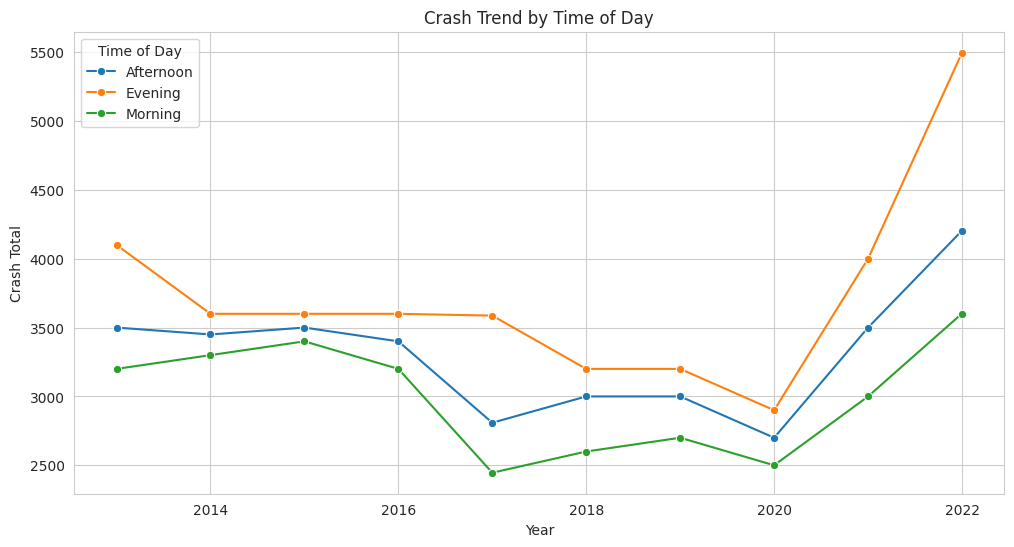

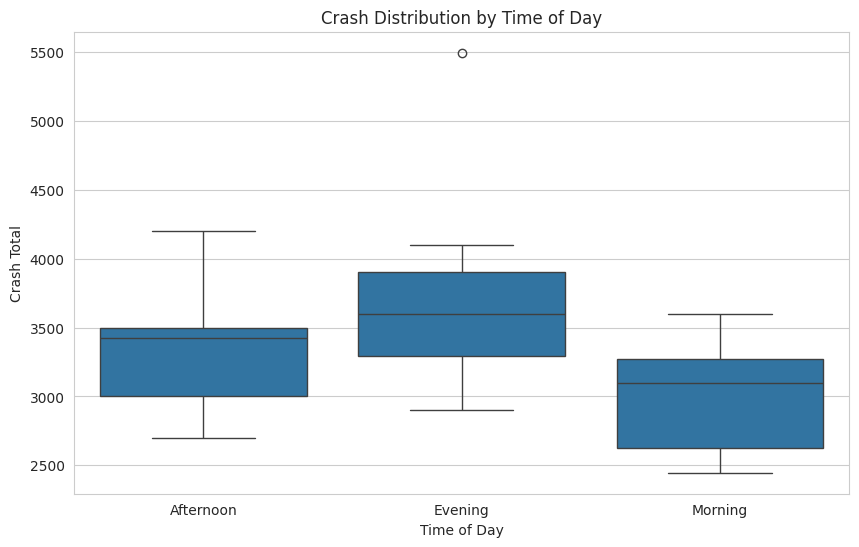

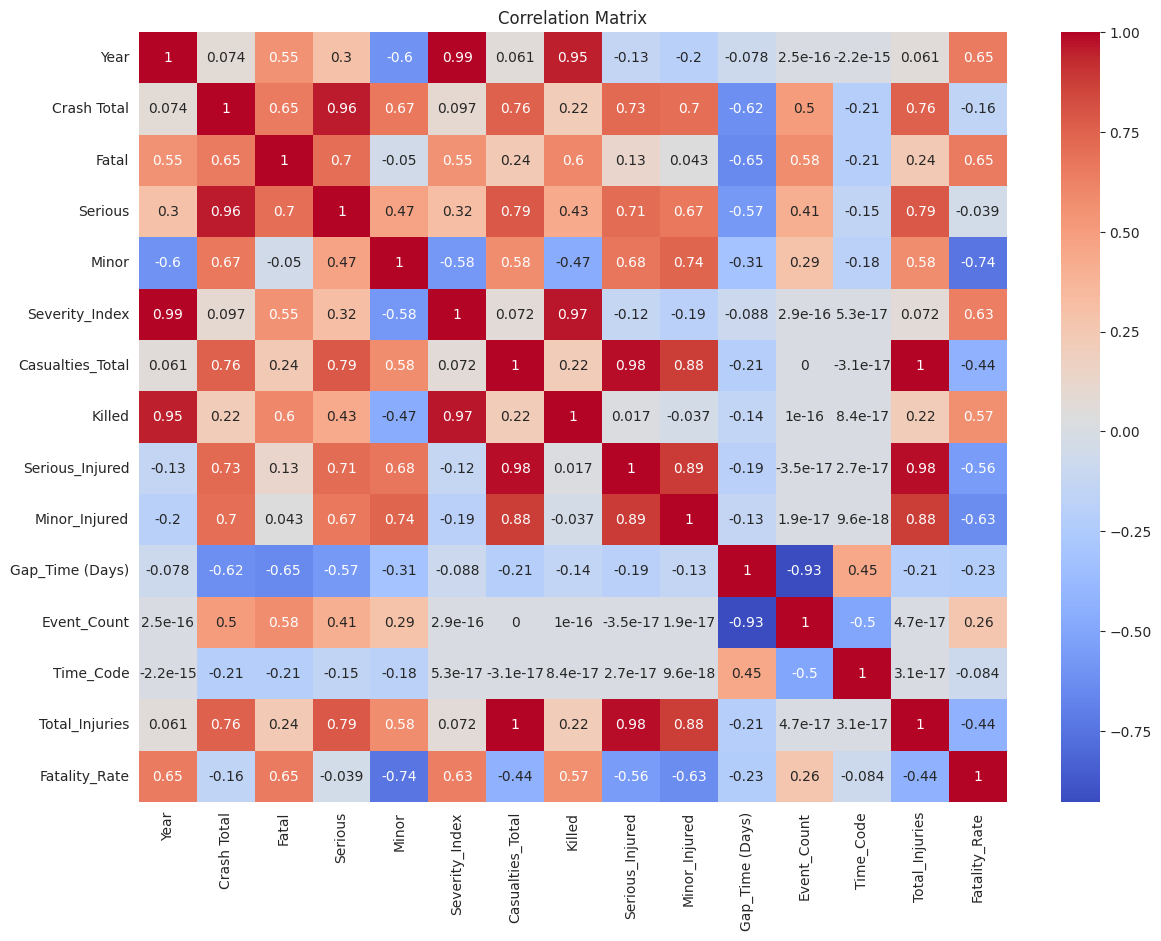

In [ ]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson
from scipy.stats import gamma
from scipy.linalg import eig

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report

from hmmlearn.hmm import PoissonHMM
from hmmlearn.hmm import GaussianHMM

from lifelines import CoxPHFitter
from lifelines import WeibullAFTFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

from statsmodels.stats.diagnostic import acorr_ljungbox

import mdptoolbox
import mdptoolbox.example

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# =========================================================
# DATA INFORMATION
# =========================================================

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
print(df.describe())

# =========================================================
# DATA CLEANING
# =========================================================

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values if any
df = df.fillna(method='ffill')

# Convert Time of Day into numeric labels
encoder = LabelEncoder()
df['Time_Code'] = encoder.fit_transform(df['Time of Day'])

# Create Total Injuries Variable
df['Total_Injuries'] = (
    df['Killed'] +
    df['Serious_Injured'] +
    df['Minor_Injured']
)

# Create Severity Ratio
df['Fatality_Rate'] = df['Fatal'] / df['Crash Total']

# Sort values
df = df.sort_values(by=['Year', 'Time_Code'])

df.head()

# =========================================================
# EXPLORATORY DATA ANALYSIS
# =========================================================

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Year', y='Crash Total', hue='Time of Day', marker='o')
plt.title('Crash Trend by Time of Day')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Time of Day', y='Crash Total')
plt.title('Crash Distribution by Time of Day')
plt.show()

# Correlation Matrix

plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

OBJECTIVE ONE: HIDDEN MARKOV MODEL (HMM)

    Year Time of Day  Crash Total  Hidden_State
1   2013   Afternoon         3500             1
2   2013     Evening         4100             0
0   2013     Morning         3200             1
4   2014   Afternoon         3450             1
5   2014     Evening         3600             1
3   2014     Morning         3300             1
7   2015   Afternoon         3500             1
8   2015     Evening         3600             1
6   2015     Morning         3400             1
10  2016   Afternoon         3400             1
11  2016     Evening         3600             1
9   2016     Morning         3200             1
13  2017   Afternoon         2809             2
14  2017     Evening         3587             1
12  2017     Morning         2446             2
16  2018   Afternoon         3000             2
17  2018     Evening         3200             1
15  2018     Morning         2600             2
19  2019   Afternoon         3000             2
20  2019     Evening         3200       

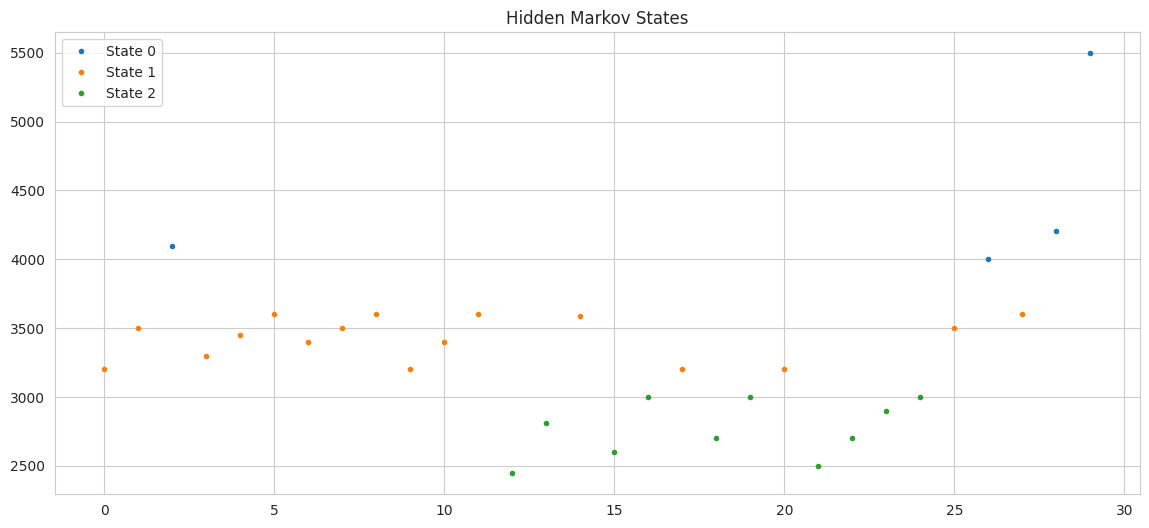

Log Likelihood: -463.78901841744994
Next State Probabilities
[0.13333333 0.6        0.26666667]


In [ ]:
# OBJECTIVE ONE
# HIDDEN MARKOV MODEL (HMM)

# =========================================================
# FIT POISSON HMM
# =========================================================

# Prepare the data for the HMM model
X = df['Crash Total'].values.reshape(-1, 1)

model = PoissonHMM(
    n_components=3,
    n_iter=1000,
    random_state=42
)

model.fit(X)

# Predict hidden states
hidden_states = model.predict(X)

df['Hidden_State'] = hidden_states

print(df[['Year', 'Time of Day', 'Crash Total', 'Hidden_State']])

# =========================================================
# TRANSITION MATRIX
# =========================================================

transition_matrix = model.transmat_

print("Transition Probability Matrix")
print(transition_matrix)

# =========================================================
# STATE POISSON RATES
# =========================================================

print("Poisson Means per Hidden State")

for i, mean in enumerate(model.lambdas_):
    print(f"State {i}: {mean}")

# =========================================================
# VISUALIZE HIDDEN STATES
# =========================================================

plt.figure(figsize=(14,6))

for i in range(model.n_components):
    state = (hidden_states == i)

    plt.plot(
        df.index[state],
        df['Crash Total'][state],
        '.',
        label=f'State {i}'
    )

plt.legend()
plt.title('Hidden Markov States')
plt.show()

# =========================================================
# LOG LIKELIHOOD
# =========================================================

log_likelihood = model.score(X)

print("Log Likelihood:", log_likelihood)

# =========================================================
# FORECAST NEXT STATE
# =========================================================

last_state = hidden_states[-1]

next_state_prob = transition_matrix[last_state]

print("Next State Probabilities")
print(next_state_prob)

MARKOV MODULATED POISSON PROCESS APPROXIMATION

In [ ]:
# =========================================================
# CREATE RISK STATES
# =========================================================

conditions = [
    df['Crash Total'] < 3000,
    (df['Crash Total'] >= 3000) & (df['Crash Total'] < 4000),
    df['Crash Total'] >= 4000
]

choices = ['Low', 'Medium', 'High']

df['Risk_State'] = np.select(conditions, choices, default=None)

df[['Crash Total', 'Risk_State']].head()

# =========================================================
# MARKOV TRANSITION MATRIX
# =========================================================

states = ['Low', 'Medium', 'High']

transition_counts = pd.DataFrame(
    0,
    index=states,
    columns=states
)

for i in range(len(df)-1):
    current_state = df['Risk_State'].iloc[i]
    next_state = df['Risk_State'].iloc[i+1]

    transition_counts.loc[current_state, next_state] += 1

transition_prob = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

print("Transition Counts")
print(transition_counts)

print("\nTransition Probabilities")
print(transition_prob)

Transition Counts
        Low  Medium  High
Low       3       4     0
Medium    4      11     3
High      0       3     1

Transition Probabilities
             Low    Medium      High
Low     0.428571  0.571429  0.000000
Medium  0.222222  0.611111  0.166667
High    0.000000  0.750000  0.250000


OBJECTIVE TWO: SURVIVAL ANALYSIS

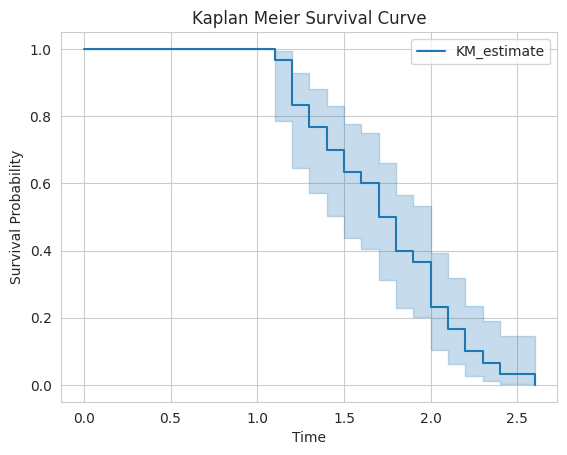

<lifelines.CoxPHFitter: fitted with 30 total observations, 0 right-censored observations>
             duration col = 'Gap_Time (Days)'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 30
number of events observed = 30
   partial log-likelihood = -66.76
         time fit was run = 2026-05-17 16:47:39 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Crash Total     0.00      1.00      0.00            0.00            0.00                1.00                1.00
Severity_Index  0.74      2.09      0.96           -1.15            2.63                0.32               13.83

                cmp to    z      p  -log2(p)
covariate                                   
Crash Total       0.00 3.79 <0.005     12.72
Severity_Index    0.00 0.77   0.44      1.17
---
Concordance = 0.76
Partial AIC = 137.52
log-likelihood ratio test = 15.80 on 2 df
-log2(p) of ll-ratio test = 11.40

<lifelines.WeibullAFTFitter: fitted with 30 total observations, 0 right-censored observations>
             duration col = 'Gap_Time (Days)'
                event col = 'event'
   number of observations = 30
number of events observed = 30
           log-likelihood = -7.40
         time fit was run = 2026-05-17 16:47:39 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                       
lambda_ Crash Total    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        Severity_Index -0.12      0.89      0.15           -0.41            0.17                0.67                1.19
        Intercept       1.73      5.66      0.35            1.05            2.41                2.86               11.18
rho_    Intercept       1.83      6.26      0.14            1.56            2.11                4.74                8.28

                        cmp to     z      p  -log2(p)
param   covariate                                    
lambda_ Crash Total       0.00 -5.18 <0.005     22.09
        Severity_Index    0.00 -0.79   0.43      1.23
        Intercept         0.00  4.98 <0.005     20.61
rho_    Intercept         0.00 12.87 <0.005    123.59
---
Concordance = 0.76
AIC = 22.81
log-likelihood ratio test = 15.71 on 2 df
-log2(p) of ll-ratio test = 11.33

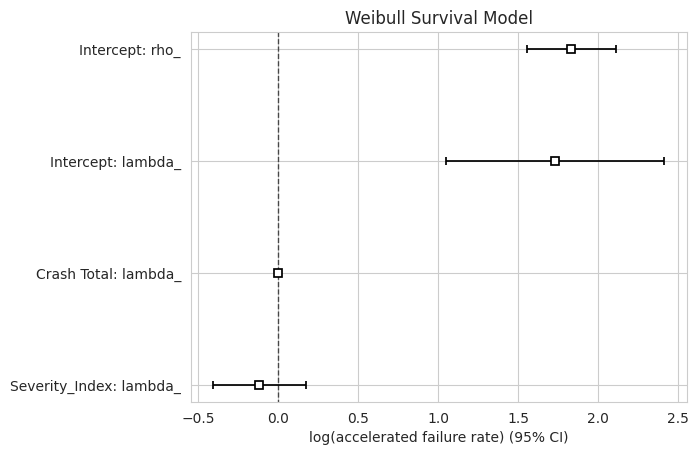

In [ ]:
# =========================================================
# KAPLAN MEIER MODEL
# =========================================================

kmf = KaplanMeierFitter()

T = df['Gap_Time (Days)']
E = np.ones(len(df))

kmf.fit(T, event_observed=E)

kmf.plot_survival_function()

plt.title('Kaplan Meier Survival Curve')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.show()

# =========================================================
# COX PROPORTIONAL HAZARD MODEL
# =========================================================

survival_df = df[[
    'Gap_Time (Days)',
    'Crash Total',
    'Severity_Index'
]]

survival_df['event'] = 1

cph = CoxPHFitter()

cph.fit(
    survival_df,
    duration_col='Gap_Time (Days)',
    event_col='event'
)

cph.print_summary()

# =========================================================
# WEIBULL AFT MODEL
# =========================================================

aft = WeibullAFTFitter()

aft.fit(
    survival_df,
    duration_col='Gap_Time (Days)',
    event_col='event'
)

aft.print_summary()

# =========================================================
# PLOT SURVIVAL FUNCTION
# =========================================================

aft.plot()

plt.title("Weibull Survival Model")
plt.show()

FRAILTY MODEL APPROXIMATION

In [ ]:
# =========================================================
# Regional Frailty Proxy
# =========================================================

np.random.seed(42)

df['Frailty'] = np.random.gamma(
    shape=2,
    scale=1,
    size=len(df)
)

df[['Frailty']].head()

# =========================================================
# Extended Cox Model with Frailty Proxy
# =========================================================

frailty_df = df[[
    'Gap_Time (Days)',
    'Crash Total',
    'Severity_Index',
    'Frailty'
]]

frailty_df['event'] = 1

cph2 = CoxPHFitter()

cph2.fit(
    frailty_df,
    duration_col='Gap_Time (Days)',
    event_col='event'
)

cph2.print_summary()

<lifelines.CoxPHFitter: fitted with 30 total observations, 0 right-censored observations>
             duration col = 'Gap_Time (Days)'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 30
number of events observed = 30
   partial log-likelihood = -66.30
         time fit was run = 2026-05-17 16:52:04 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Crash Total     0.00      1.00      0.00            0.00            0.00                1.00                1.00
Severity_Index  0.87      2.38      0.99           -1.08            2.81                0.34               16.63
Frailty        -0.22      0.81      0.23           -0.66            0.23                0.52                1.26

                cmp to     z      p  -log2(p)
covariate                                    
Crash Total       0.00  3.90 <0.005     13.36
Severity_Index    0.00  0.87   0.38      1.38
Frailty           0.00 -0.94   0.35      1.53
---
Concordance = 0.75
Partial AIC = 138.59
log-likelihood ratio test = 16.72 on 3 df
-log2(p) of ll-ratio test = 10.28

COMPETING RISKS ANALYSIS

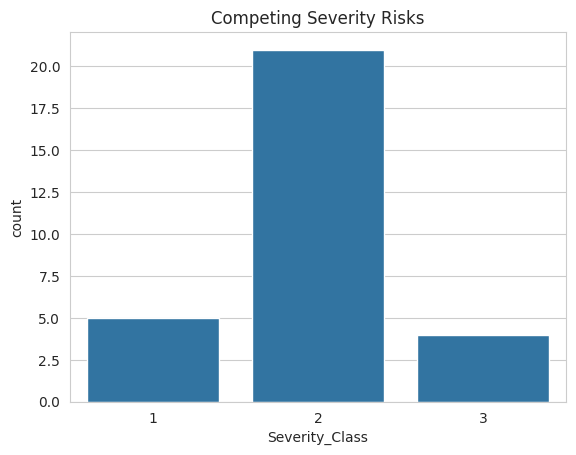

In [ ]:
# =========================================================
# Severity Event Classification
# =========================================================

def classify_severity(x):

    if x >= 800:
        return 3

    elif x >= 500:
        return 2

    else:
        return 1

df['Severity_Class'] = df['Fatal'].apply(classify_severity)

df[['Fatal', 'Severity_Class']].head()

# =========================================================
# SEVERITY DISTRIBUTION
# =========================================================

sns.countplot(
    data=df,
    x='Severity_Class'
)

plt.title('Competing Severity Risks')
plt.show()

OBJECTIVE THREE: ONLINE PREDICTION OF ACCIDENT HOTSPOTS

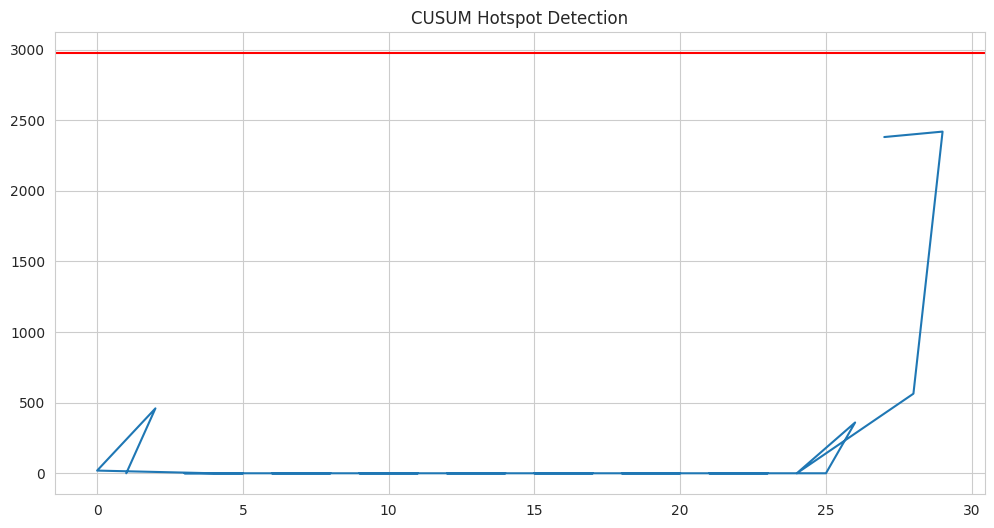

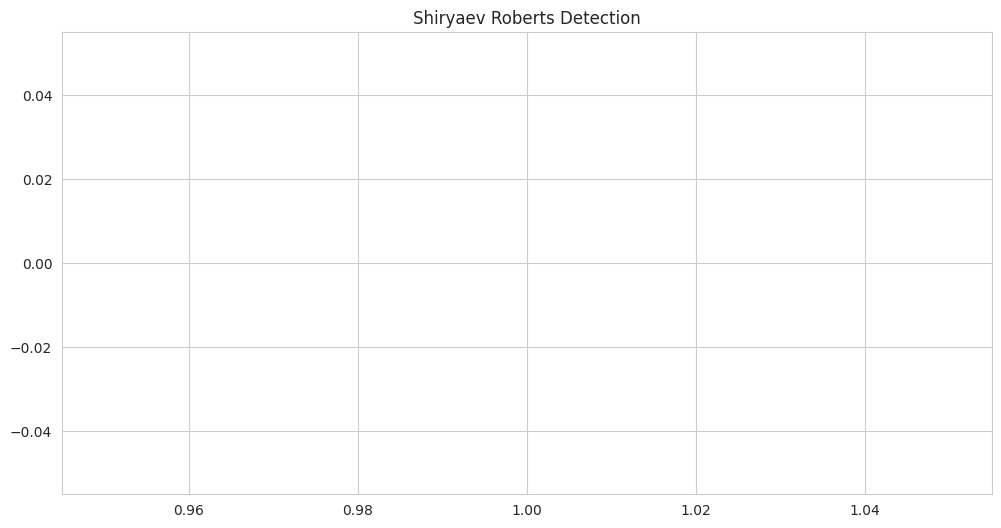

,Year,Time of Day,CUSUM,Hotspot
1,2013,Afternoon,0.000000,0
2,2013,Evening,459.513237,0
0,2013,Morning,19.026474,0
4,2014,Afternoon,0.000000,0
5,2014,Evening,0.000000,0
3,2014,Morning,0.000000,0
7,2015,Afternoon,0.000000,0
8,2015,Evening,0.000000,0
6,2015,Morning,0.000000,0
10,2016,Afternoon,0.000000,0


In [ ]:
# =========================================================
# CUSUM DETECTION
# =========================================================

crashes = df['Crash Total'].values

target = np.mean(crashes)

k = 0.5 * np.std(crashes)

h = 5 * np.std(crashes)

cusum_pos = [0]

for i in range(1, len(crashes)):

    s = max(
        0,
        cusum_pos[i-1] + crashes[i] - target - k
    )

    cusum_pos.append(s)

df['CUSUM'] = cusum_pos

plt.figure(figsize=(12,6))

plt.plot(df['CUSUM'])

plt.axhline(h, color='red')

plt.title('CUSUM Hotspot Detection')

plt.show()

# =========================================================
# Shiryaev Roberts Procedure
# =========================================================

sr = [0]

for i in range(1, len(crashes)):

    likelihood_ratio = np.exp(
        crashes[i] - target
    )

    sr_stat = (1 + sr[i-1]) * likelihood_ratio

    sr.append(sr_stat)

df['SR_Statistic'] = sr

plt.figure(figsize=(12,6))

plt.plot(df['SR_Statistic'])

plt.title('Shiryaev Roberts Detection')

plt.show()

# =========================================================
# HOTSPOT DETECTION
# =========================================================

threshold = np.percentile(df['CUSUM'], 90)

df['Hotspot'] = np.where(
    df['CUSUM'] > threshold,
    1,
    0
)

df[['Year', 'Time of Day', 'CUSUM', 'Hotspot']]

MONTE CARLO SIMULATION and MARKOV DECISION PROCESS

In [ ]:
# =========================================================
# MONTE CARLO SIMULATION
# =========================================================

np.random.seed(42)

simulated_bias = []
simulated_mse = []

for i in range(100):

    simulated = np.random.poisson(
        lam=np.mean(df['Crash Total']),
        size=len(df)
    )

    bias = np.mean(simulated) - np.mean(df['Crash Total'])

    mse = mean_squared_error(
        df['Crash Total'],
        simulated
    )

    simulated_bias.append(bias)
    simulated_mse.append(mse)

print("Average Bias:", np.mean(simulated_bias))
print("Average MSE:", np.mean(simulated_mse))

# =========================================================
# Define States and Actions
# MDP MODEL
# =========================================================

# States:
# 0 = Low Risk
# 1 = Medium Risk
# 2 = High Risk

# Actions:
# 0 = No Patrol
# 1 = Moderate Patrol
# 2 = Intensive Patrol

P = np.array([
    [
        [0.8, 0.15, 0.05],
        [0.7, 0.2, 0.1],
        [0.6, 0.25, 0.15]
    ],

    [
        [0.2, 0.6, 0.2],
        [0.15, 0.7, 0.15],
        [0.1, 0.75, 0.15]
    ],

    [
        [0.1, 0.2, 0.7],
        [0.05, 0.15, 0.8],
        [0.02, 0.08, 0.9]
    ]
])

R = np.array([
    [50, 40, 20],
    [30, 20, 10],
    [10, 5, -20]
])

mdp = mdptoolbox.mdp.ValueIteration(
    P,
    R,
    0.95
)

mdp.run()

print("Optimal Policy")
print(mdp.policy)

Average Bias: -1.4229999999998926
Average MSE: 356867.5203333333
Optimal Policy
(0, 0, 0)


MODEL DIAGNOSTICS

In [ ]:
# =========================================================
# Residual Diagnostics
# LJUNG BOX TEST
# =========================================================

lb_test = acorr_ljungbox(
    df['Crash Total'],
    lags=[5],
    return_df=True
)

print(lb_test)

# =========================================================
# PREDICTION PERFORMANCE
# =========================================================

predicted_states = model.predict(X)

accuracy = np.mean(predicted_states == hidden_states)

print("Prediction Accuracy:", accuracy)

     lb_stat  lb_pvalue
5  10.215101   0.069365
Prediction Accuracy: 1.0


EXPORTING OUTPUT To EXCEL

In [ ]:
# =========================================================
# EXPORT RESULTS
# =========================================================

df.to_excel(
    "Rugasira_Final_Analysis_Output.xlsx",
    index=False
)

print("Analysis Complete")

# =========================================================
# DOWNLOAD OUTPUT
# =========================================================

from google.colab import files

files.download("Rugasira_Final_Analysis_Output.xlsx")

Analysis Complete


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>